In [118]:
import os
import sys
import glob
import json
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 11})

In [119]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

figureroot = "./results/system_03/lyapunov"
os.makedirs(figureroot, exist_ok=True)

In [120]:
load_dir = "../system_03/results/lyapunov/"
load_str = datetime.datetime(2024, 3, 31)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 220


In [121]:
sigVar = np.array([0.01, 0.1, 1, 2])
iE = 0.25 / params['gamma'] - params['i_e2']

iPert = np.array([0, 0.15, 0.25, 0.35, 0.5]) / params['gamma']
kMin = -1; kMax = 1; kSteps = 10
kVals = kMin + np.arange(0, kSteps) / kSteps * (kMax - kMin)

seVals = np.array([2.5, 7.5, 13.5]); seSteps = len(seVals)
siVals = np.array([4.4, 13.5, 16.5]); siSteps = len(siVals) 

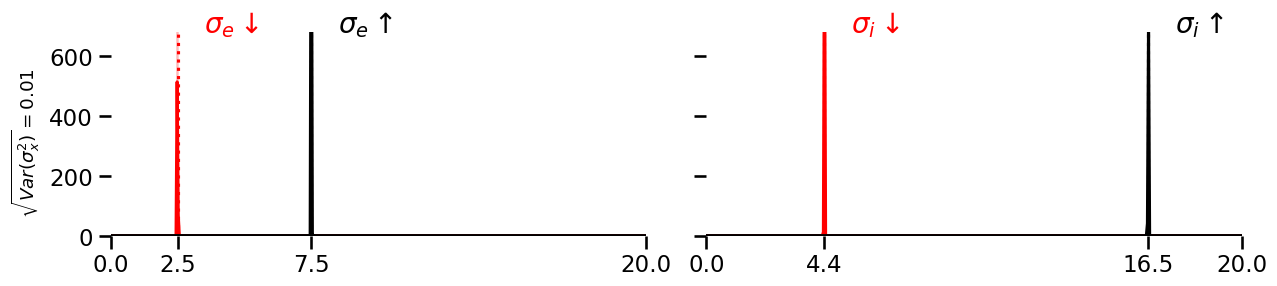

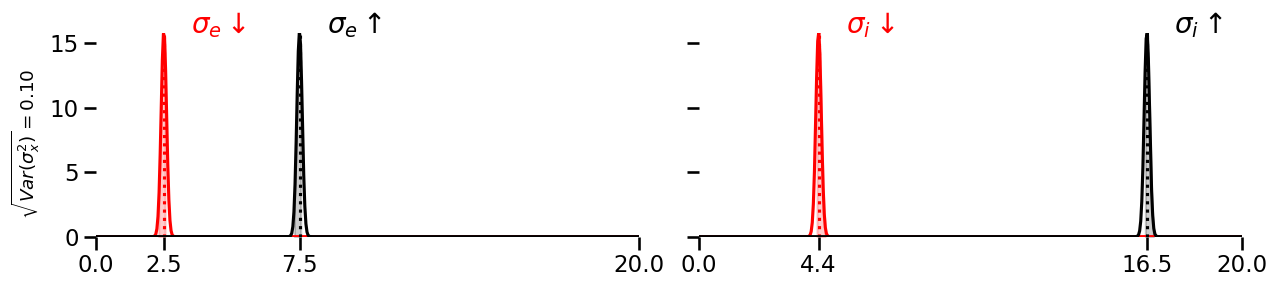

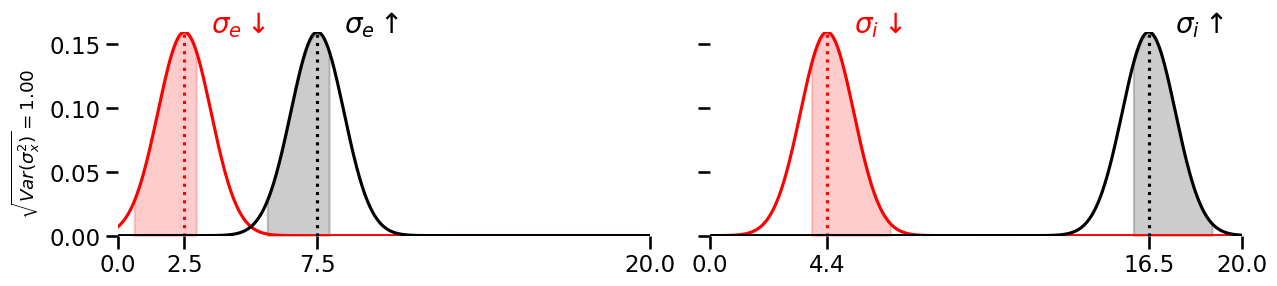

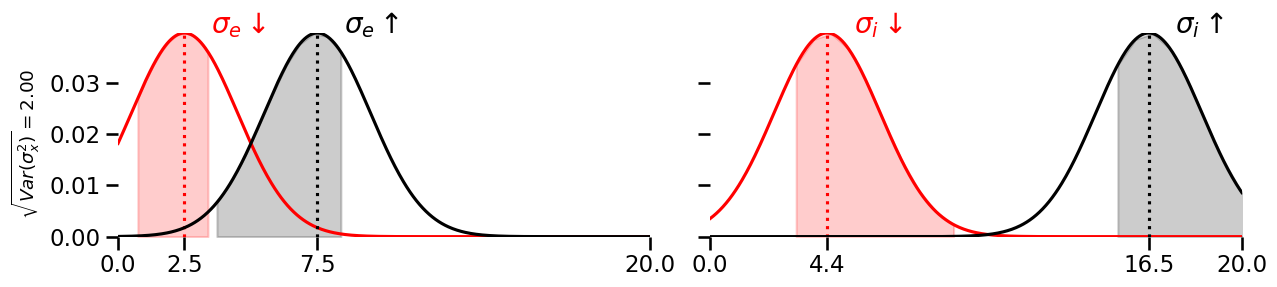

In [158]:
n_trials = 10
COLORS = ['r', 'k']

weights = np.linspace(0, 20, 500)
normdistribution = lambda x, mean, sigma : (1 / (2 * np.pi * sigma **2)) * np.exp(-(x - mean) ** 2 / (2 * sigma ** 2))



for _sigvar in sigVar:

    sige_node2 = np.zeros((seSteps, siSteps, n_trials))
    sigi_node2 = np.zeros((seSteps, siSteps, n_trials))

    for se, sigma_e in enumerate(seVals):
        for si, sigma_i in enumerate(siVals):
            for q in range(n_trials):
                np.random.seed(q * 10 + 5)
                sige2 = abs(np.random.normal(sigma_e, _sigvar, 1))
                sigi2 = abs(np.random.normal(sigma_i, _sigvar, 1))

                sige_node2[se, si, q] = sige2[0]
                sigi_node2[se, si, q] = sigi2[0]

    
    fig, axs = plt.subplots(1, 2, sharey=True, figsize=(13, 3))
    for i in range(seSteps):
        if i == 2:
            continue
        _sampledw = sige_node2[i, 0, :]
        _sampledw = np.linspace(min(_sampledw), max(_sampledw), 10)
        _samplew_prob = normdistribution(_sampledw, seVals[i], _sigvar)

        axs[0].plot(weights, normdistribution(weights, seVals[i], _sigvar), color=COLORS[i])
        axs[0].fill_between(_sampledw, _samplew_prob, color=COLORS[i], alpha=0.2)
        axs[0].axvline(seVals[i], color=COLORS[i], linestyle=":")
        
        axs[0].set_xlim(0, 20)
        axs[0].set_xticks([0, 2.5, 7.5, 20])
        axs[0].set_ylim(0, max(normdistribution(weights, seVals[i], _sigvar)))
        y_max = max(normdistribution(weights, seVals[i], _sigvar))

    for i in range(siSteps):
        if i == 1:
            continue
        _sampledw = sigi_node2[0, i, :]
        _sampledw = np.linspace(min(_sampledw), max(_sampledw), 10)
        _samplew_prob = normdistribution(_sampledw, siVals[i], _sigvar)
        axs[1].plot(weights, normdistribution(weights, siVals[i], _sigvar), color=COLORS[i//2])
        axs[1].fill_between(_sampledw, _samplew_prob, color=COLORS[i//2], alpha=0.2)
        axs[1].axvline(siVals[i], color=COLORS[i//2], linestyle=":")

        axs[1].set_xlim(0, 20)
        axs[1].set_xticks([0, 4.4, 16.5, 20])
        axs[1].set_ylim(0, max(normdistribution(weights, siVals[i], _sigvar)))
        y_max = max(normdistribution(weights, siVals[i], _sigvar))

    for pos in ["right", "left", "top", "bottom"]:
        axs[0].spines[pos].set_visible(False)
        axs[1].spines[pos].set_visible(False)

    axs[0].text(seVals[0] + 1, y_max, r"$\sigma_e \downarrow$", color='r', fontsize=20)
    axs[0].text(seVals[1] + 1, y_max, r"$\sigma_e \uparrow$", color='k', fontsize=20)
    axs[1].text(siVals[0] + 1, y_max, r"$\sigma_i \downarrow$", color='r', fontsize=20)
    axs[1].text(siVals[2] + 1, y_max, r"$\sigma_i \uparrow$", color='k', fontsize=20)

    fig.supylabel(r"$\sqrt{Var(\sigma_x^2)} = $" + f"{_sigvar:.2f}")
    plt.tight_layout()
    plt.savefig(os.path.join(figureroot, f"samplingdistribution_var_{_sigvar:.2f}.png"), dpi=300, bbox_inches="tight")

In [159]:
_temp = []
_sortpaths = []

varInd = 3
for path_ in file_paths:
    if f"_{iE + params['i_e2']:.3f}_sigVar_{sigVar[varInd]:.2f}" not in path_:
        continue

    Basename = os.path.basename(path_).split('.pkl')[0]
    K = float(Basename.split('_K_')[-1].split('_ie_')[0])
    _temp.append(K)
    _sortpaths.append(path_)

_temp = np.array(_temp)
Ksort = np.argsort(_temp)

_sortpaths = np.array(_sortpaths)
_sortpaths = _sortpaths[Ksort]

In [160]:
Lyap = np.zeros((kSteps + 1, 4))
LyapVar = np.zeros((kSteps + 1, 4))
sigE = np.zeros((kSteps + 1, 4))
sigI = np.zeros((kSteps + 1, 4))

for nf, path_ in enumerate(_sortpaths):

    lyap_results = pickle.load(open(path_, 'rb'))

    _lyapMean = lyap_results['n1_mean']
    _lyapVar = lyap_results['n1_var']

    
    sigE[nf, 0] = seVals[0]; sigI[nf, 0] = siVals[0]; Lyap[nf, 0] = lyap_results[0, 0]
    sigE[nf, 1] = seVals[0]; sigI[nf, 1] = siVals[-1]; Lyap[nf, 1] = lyap_results[0, -1]
    sigE[nf, 2] = seVals[-2]; sigI[nf, 2] = siVals[2]; Lyap[nf, 2] = lyap_results[-2, 2]
    sigE[nf, 3] = seVals[-2]; sigI[nf, 3] = siVals[-1]; Lyap[nf, 3] = lyap_results[-2, -1]

if len(lyap_results[lyap_results != -np.inf].flatten()) == 0:
    minValue = -15
else:
    minValue = min(lyap_results[lyap_results != -np.inf])
lyap_results[lyap_results == -np.inf] = minValue

In [ ]:
colors= plt.get_cmap('jet')
colorIter = iter(colors(np.linspace(0.3, 1, 4)))

plt.figure(figsize=(8, 3))

plt.plot(kVals[:-1], Lyap[:-1, 0], '.-', color = 'b', linewidth=1.5)
plt.fill_between(kVals[:-1], )
plt.text(-0.55, -2.2, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{3.97}$', color = 'b',  fontsize=16)

plt.plot(kVals, Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
plt.text(-0.65, -8, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = 'g',  fontsize=16)

plt.plot(kVals, Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
plt.text(-0.4, 3, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{9.87}{3.97}$', color = 'r',  fontsize=16)

plt.plot(kVals, Lyap[:, 3], '.-', color = 'purple', linewidth=1.5)
plt.text(0.12, -10, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} = \genfrac{[}{]}{0}{1}{9.87}{16.5}$', color = 'purple',  fontsize=16)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\bar{\lambda}^1_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
plt.xlim(kMin, max(kVals))
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_K.png"), dpi=300, bbox_inches='tight')
    